# PyGaborSTM Benchmark
Compares CPU vs GPU, separate stages vs chained pipeline, and cached vs cold runs.

In [1]:
import cupy as cp
print(f"CuPy {cp.__version__}, CUDA available: {cp.cuda.is_available()}, Device: {cp.cuda.Device(0).id}")

CuPy 14.0.1, CUDA available: True, Device: 0


In [2]:
N_FILTERS = 256
FRMLEN_MS = 8.0
RIPPLE_F_MIN = 1000 / (2 ** (5.3 / 2))
RIPPLE_OCTAVES = 5.3
RESOLUTION = "low"
SR = 16000
DURATION = 5.0

In [3]:
import sys, re, time
sys.path.insert(0, "..")

import numpy as np
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import pygaborstm as stm

shared_kwargs = dict(
    resolution=RESOLUTION,
    n_filters=N_FILTERS,
    frmlen_ms=FRMLEN_MS,
    f_min=RIPPLE_F_MIN,
    octaves=RIPPLE_OCTAVES,
)
model_cpu = stm.PyGaborSTM(stm.Config(use_gpu=False, **shared_kwargs))
model_gpu = stm.PyGaborSTM(stm.Config(use_gpu=True, **shared_kwargs))

print(f"PyGaborSTM {stm.__version__}")
print(f"Resolution: {RESOLUTION}, Filters: {N_FILTERS}, Frame: {FRMLEN_MS}ms")

/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


PyGaborSTM 0.1.0
Resolution: low, Filters: 256, Frame: 8.0ms


In [4]:
DATA_DIR = Path("./data")
RIPPLE_DIR = DATA_DIR / "mvripfft"

def load_audio(filepath):
    audio, _ = librosa.load(filepath, sr=SR)
    max_samples = int(DURATION * SR)
    return audio[:max_samples] if len(audio) > max_samples else audio

def parse_ripple_filename(filename):
    match = re.search(r'R(-?\d+\.?\d*)_S(\d+\.?\d*)', filename.stem)
    return float(match.group(1)), float(match.group(2))

valid_rates = set(model_cpu.config.rates)
valid_scales = set(model_cpu.config.scales)

audios = []
for filepath in sorted(RIPPLE_DIR.glob("ripple_*.wav")):
    rate, scale = parse_ripple_filename(filepath)
    if rate in valid_rates and scale in valid_scales:
        audios.append(load_audio(filepath))

print(f"Loaded {len(audios)} files, {audios[0].shape[0]/SR:.1f}s each")

Loaded 60 files, 5.0s each


## Warmup (builds caches, JIT compiles CUDA kernels)

In [5]:
_ = model_cpu.compute(audios[0])
_ = model_gpu.compute(audios[0])
print("Warmup done (caches built)")

Warmup done (caches built)


## Single file benchmark

In [6]:
audio = audios[0]
results_single = {}

# CPU: separate stages
start = time.perf_counter()
spec = model_cpu.spectrogram(audio)
rsf = model_cpu.rsf(spec)
results_single['CPU separate'] = time.perf_counter() - start

# CPU: chained pipeline
start = time.perf_counter()
rsf = model_cpu.compute(audio)
results_single['CPU compute()'] = time.perf_counter() - start

# GPU: separate stages
start = time.perf_counter()
spec = model_gpu.spectrogram(audio)
rsf = model_gpu.rsf(spec)
results_single['GPU separate'] = time.perf_counter() - start

# GPU: compute() (chained, host transfer at end)
start = time.perf_counter()
rsf = model_gpu.compute(audio)
results_single['GPU compute()'] = time.perf_counter() - start

# GPU: compute_device() (chained, NO host transfer)
start = time.perf_counter()
rsf_dev = model_gpu.compute_device(audio)
results_single['GPU compute_device()'] = time.perf_counter() - start

print("Single file results:")
for name, t in results_single.items():
    speedup = results_single['CPU separate'] / t
    print(f"  {name:<25s} {t:.3f}s  ({speedup:.1f}x vs CPU separate)")

Single file results:
  CPU separate              2.829s  (1.0x vs CPU separate)
  CPU compute()             2.772s  (1.0x vs CPU separate)
  GPU separate              0.413s  (6.9x vs CPU separate)
  GPU compute()             0.188s  (15.1x vs CPU separate)
  GPU compute_device()      0.092s  (30.6x vs CPU separate)


## Full batch benchmark (all files)

In [7]:
results_batch = {}

# CPU: separate stages
start = time.perf_counter()
for audio in audios:
    spec = model_cpu.spectrogram(audio)
    rsf = model_cpu.rsf(spec)
results_batch['CPU separate'] = time.perf_counter() - start

# CPU: chained pipeline
start = time.perf_counter()
for audio in audios:
    rsf = model_cpu.compute(audio)
results_batch['CPU compute()'] = time.perf_counter() - start

# GPU: separate stages
start = time.perf_counter()
for audio in audios:
    spec = model_gpu.spectrogram(audio)
    rsf = model_gpu.rsf(spec)
results_batch['GPU separate'] = time.perf_counter() - start

# GPU: compute() (chained)
start = time.perf_counter()
for audio in audios:
    rsf = model_gpu.compute(audio)
results_batch['GPU compute()'] = time.perf_counter() - start

# GPU: compute_device() (chained, no host transfer)
start = time.perf_counter()
for audio in audios:
    rsf_dev = model_gpu.compute_device(audio)
results_batch['GPU compute_device()'] = time.perf_counter() - start

print(f"Batch results ({len(audios)} files):")
for name, t in results_batch.items():
    speedup = results_batch['CPU separate'] / t
    per_file = t / len(audios)
    print(f"  {name:<25s} {t:7.2f}s  ({per_file:.3f}s/file, {speedup:.1f}x vs CPU)")

Batch results (60 files):
  CPU separate               134.83s  (2.247s/file, 1.0x vs CPU)
  CPU compute()              138.65s  (2.311s/file, 1.0x vs CPU)
  GPU separate                 9.33s  (0.155s/file, 14.5x vs CPU)
  GPU compute()               10.58s  (0.176s/file, 12.7x vs CPU)
  GPU compute_device()         9.02s  (0.150s/file, 15.0x vs CPU)


## Stage breakdown (GPU)

In [8]:
start = time.perf_counter()
specs = [model_gpu.spectrogram(audio) for audio in audios]
gpu_spec_time = time.perf_counter() - start

start = time.perf_counter()
rsfs = [model_gpu.rsf(spec) for spec in specs]
gpu_rsf_time = time.perf_counter() - start

print(f"GPU spectrogram: {gpu_spec_time:.2f}s ({gpu_spec_time/len(audios):.3f}s/file)")
print(f"GPU RSF:         {gpu_rsf_time:.2f}s ({gpu_rsf_time/len(audios):.3f}s/file)")
print(f"Spec is {gpu_spec_time / (gpu_spec_time + gpu_rsf_time) * 100:.0f}% of GPU total")

GPU spectrogram: 7.16s (0.119s/file)
GPU RSF:         1.76s (0.029s/file)
Spec is 80% of GPU total


## VRAM usage

In [9]:
mempool = cp.get_default_memory_pool()
print(f"GPU memory used:  {mempool.used_bytes() / 1e9:.2f} GB")
print(f"GPU memory pool:  {mempool.total_bytes() / 1e9:.2f} GB")

GPU memory used:  0.81 GB
GPU memory pool:  8.87 GB


## Results

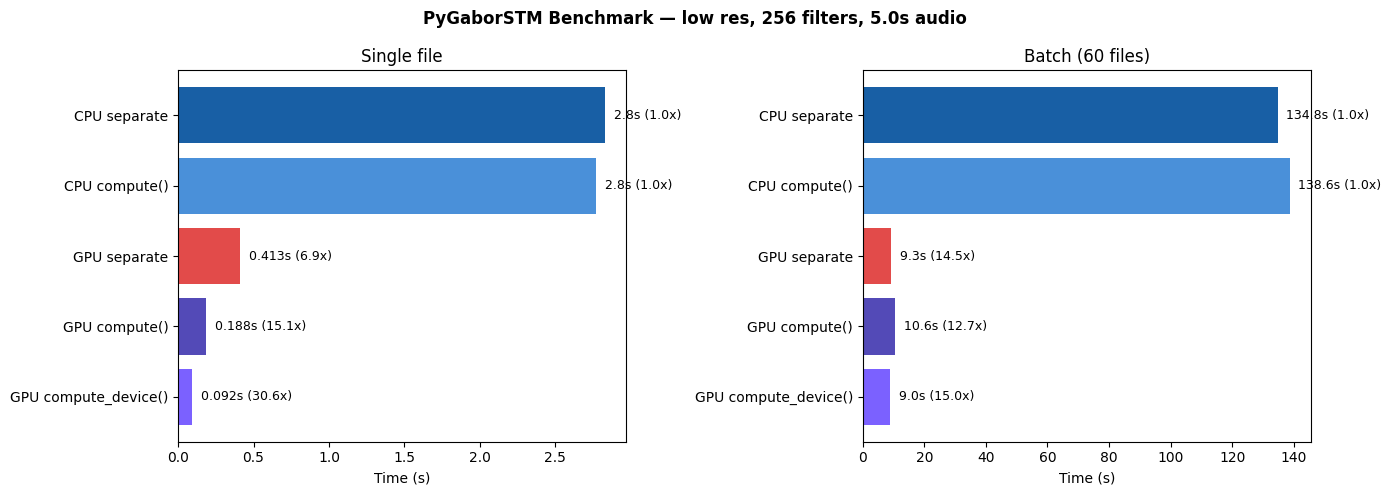

Saved benchmark_results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#185FA5', '#4A90D9', '#E24B4A', '#534AB7', '#7B61FF']

for ax, title, results in [
    (axes[0], 'Single file', results_single),
    (axes[1], f'Batch ({len(audios)} files)', results_batch),
]:
    names = list(results.keys())
    times = list(results.values())
    bars = ax.barh(names, times, color=colors[:len(names)])
    ax.set_xlabel('Time (s)')
    ax.set_title(title)
    ax.invert_yaxis()

    cpu_baseline = results['CPU separate']
    for bar, t in zip(bars, times):
        speedup = cpu_baseline / t
        label = f'{t:.3f}s' if t < 1 else f'{t:.1f}s'
        label += f' ({speedup:.1f}x)'
        ax.text(bar.get_width() + max(times) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', fontsize=9)

fig.suptitle(
    f'PyGaborSTM Benchmark — {RESOLUTION} res, {N_FILTERS} filters, {DURATION}s audio',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_results.png')